In [ ]:
import os
os.chdir("/Users/Owner/OneDrive/Desktop/")

In [ ]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from random import shuffle

import pandas as pd

import pickle

from sklearn.svm import SVC,LinearSVC
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier,ExtraTreesClassifier
from sklearn import svm,metrics,preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import preprocessing
from dataset import CustomEmotionDataset

# PyTorch

In [6]:
import glob
from itertools import chain
import os
import random
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from tqdm.notebook import tqdm


print(f"Torch: {torch.__version__}")

Torch: 2.2.2+cu118


In [7]:
# Training settings
batch_size = 64 #48# 32# 32 #16 #8 #
epochs = 40
lr = 3e-5
gamma = 0.7
seed = 42
device = 'cuda'
use_cuda = torch.cuda.is_available()
print(use_cuda)

True


In [ ]:
metadata_path = "./processed_data/metadata.csv"
metadata = pd.read_csv(metadata_path)
train_metadata = metadata[metadata["split"] == "train"]
val_metadata = metadata[metadata["split"] == "val"]

In [9]:
USE_ENET2=True #False #

In [10]:
IMG_SIZE=260 if USE_ENET2 else 224 # 300 # 80 #
train_transforms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    ]
)

test_transforms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    ]
)
print(test_transforms)

Compose(
    Resize(size=(260, 260), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [11]:
#adapted from https://pytorch.org/tutorials/beginner/finetuning_torchvision_models_tutorial.html
def set_parameter_requires_grad(model, requires_grad):
    for param in model.parameters():
        param.requires_grad = requires_grad

# FER only model 

In [ ]:
kwargs = {'num_workers': 4, 'pin_memory': True} if use_cuda else {}

train_dataset = CustomEmotionDataset(metadata=train_metadata, transform=train_transforms)
test_dataset = CustomEmotionDataset(metadata=val_metadata, transform=test_transforms)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, **kwargs)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **kwargs)

print(len(train_dataset), len(test_dataset))

37408 798


In [ ]:
# Compute class distribution from metadata
unique, counts = np.unique(train_metadata["class"], return_counts=True)

# Calculate class weights
cw = 1 / counts  # Inverse frequency
cw /= cw.min()   # Normalize so the smallest weight is 1
class_weights = {int(cls): weight for cls, weight in zip(unique, cw)}

print("Class Counts:", counts)
print("Class Weights:", class_weights)


Class Counts: [4980 3794 4974 4979 4986 4979 4977 3739]
Class Weights: {0: 1.0012048192771086, 1: 1.3141802846599897, 2: 1.0024125452352233, 3: 1.0014059048001607, 4: 1.0, 5: 1.0014059048001607, 6: 1.0018083182640145, 7: 1.3335116341267719}


In [14]:
num_classes=len(train_dataset.classes)
print(num_classes)

8


In [15]:
# loss function
weights = torch.FloatTensor(list(class_weights.values())).cuda()
if False:
    criterion = nn.CrossEntropyLoss(weight=weights)
    #criterion = nn.CrossEntropyLoss()
else:
    def label_smooth(target, n_classes: int, label_smoothing=0.1):
        # convert to one-hot
        batch_size = target.size(0)
        target = torch.unsqueeze(target, 1)
        soft_target = torch.zeros((batch_size, n_classes), device=target.device)
        soft_target.scatter_(1, target, 1)
        # label smoothing
        soft_target = soft_target * (1 - label_smoothing) + label_smoothing / n_classes
        return soft_target

    def cross_entropy_loss_with_soft_target(pred, soft_target):
        #logsoftmax = nn.LogSoftmax(dim=-1)
        return torch.mean(torch.sum(- weights*soft_target * torch.nn.functional.log_softmax(pred, -1), 1))

    def cross_entropy_with_label_smoothing(pred, target):
        soft_target = label_smooth(target, pred.size(1)) #num_classes) #
        return cross_entropy_loss_with_soft_target(pred, soft_target)

    criterion=cross_entropy_with_label_smoothing

In [ ]:
from robust_optimization import RobustOptimizer
import copy
def train(model,n_epochs=epochs, learningrate=lr, robust=False):
    # optimizer
    if robust:
        optimizer = RobustOptimizer(filter(lambda p: p.requires_grad, model.parameters()), optim.Adam, lr=learningrate)
        #print(optimizer)
    else:
        optimizer=optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learningrate)
    # scheduler
    #scheduler = StepLR(optimizer, step_size=1, gamma=gamma)
    best_acc=0
    best_model=None
    for epoch in range(n_epochs):
        epoch_loss = 0
        epoch_accuracy = 0
        model.train()
        for data, label in tqdm(train_loader):
            data = data.to(device)
            label = label.to(device)

            output = model(data)
            loss = criterion(output, label)

            if robust:
                #optimizer.zero_grad()
                loss.backward()
                optimizer.first_step(zero_grad=True)
  
                # second forward-backward pass
                output = model(data)
                loss = criterion(output, label)
                loss.backward()
                optimizer.second_step(zero_grad=True)
            else:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            acc = (output.argmax(dim=1) == label).float().sum()
            epoch_accuracy += acc
            epoch_loss += loss
        epoch_accuracy /= len(train_dataset)
        epoch_loss /= len(train_dataset)
        
        model.eval()
        with torch.no_grad():
            epoch_val_accuracy = 0
            epoch_val_loss = 0
            for data, label in test_loader:
                data = data.to(device)
                label = label.to(device)

                val_output = model(data)
                val_loss = criterion(val_output, label)

                acc = (val_output.argmax(dim=1) == label).float().sum()
                epoch_val_accuracy += acc
                epoch_val_loss += val_loss
        epoch_val_accuracy /= len(test_dataset)
        epoch_val_loss /= len(test_dataset)
        print(
            f"Epoch : {epoch+1} - loss : {epoch_loss:.4f} - acc: {epoch_accuracy:.4f} - val_loss : {epoch_val_loss:.4f} - val_acc: {epoch_val_accuracy:.4f}\n"
        )
        if best_acc<epoch_val_accuracy:
            best_acc=epoch_val_accuracy
            best_model=copy.deepcopy(model.state_dict())
        #scheduler.step()
    
    if best_model is not None:
        model.load_state_dict(best_model)
        print(f"Best acc:{best_acc}")
        model.eval()
        with torch.no_grad():
            epoch_val_accuracy = 0
            epoch_val_loss = 0
            for data, label in test_loader:
                data = data.to(device)
                label = label.to(device)

                val_output = model(data)
                val_loss = criterion(val_output, label)

                acc = (val_output.argmax(dim=1) == label).float().sum()
                epoch_val_accuracy += acc
                epoch_val_loss += val_loss
        epoch_val_accuracy /= len(test_dataset)
        epoch_val_loss /= len(test_dataset)
        print(
            f"val_loss : {epoch_val_loss:.4f} - val_acc: {epoch_val_accuracy:.4f}\n"
        )
    else:
        print(f"No best model Best acc:{best_acc}")

### Finetune CNN 

In [22]:
from torchvision.models import resnet101,mobilenet_v2
import timm

In [23]:
model=timm.create_model('tf_efficientnet_b0_ns', pretrained=False)
model.classifier=torch.nn.Identity()
model.load_state_dict(torch.load('./state_vggface2_enet0_new.pt')) #_new

<All keys matched successfully>

In [24]:
model.classifier=nn.Sequential(nn.Linear(in_features=1280, out_features=num_classes)) #1792 #1280 #1536
#model.head.fc=nn.Linear(in_features=3072, out_features=num_classes)
#model.head=nn.Sequential(nn.Linear(in_features=768, out_features=num_classes))
model=model.to(device)
print(model)

EfficientNet(
  (conv_stem): Conv2dSame(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
          16, eps=

In [ ]:
set_parameter_requires_grad(model, requires_grad=False)
set_parameter_requires_grad(model.classifier, requires_grad=True)
train(model,3,0.001,robust=True)

  0%|          | 0/585 [00:00<?, ?it/s]

Epoch : 1 - loss : 0.0282 - acc: 0.4027 - val_loss : 0.0263 - val_acc: 0.5050



  0%|          | 0/585 [00:00<?, ?it/s]

Epoch : 2 - loss : 0.0258 - acc: 0.4759 - val_loss : 0.0257 - val_acc: 0.5263



  0%|          | 0/585 [00:00<?, ?it/s]

Epoch : 3 - loss : 0.0254 - acc: 0.4909 - val_loss : 0.0258 - val_acc: 0.5326

Best acc:0.5325814485549927
val_loss : 0.0258 - val_acc: 0.5326



In [26]:
set_parameter_requires_grad(model, requires_grad=True)
train(model,6,1e-4,robust=True)

  0%|          | 0/585 [00:00<?, ?it/s]

Epoch : 1 - loss : 0.0240 - acc: 0.5353 - val_loss : 0.0240 - val_acc: 0.5802



  0%|          | 0/585 [00:00<?, ?it/s]

Epoch : 2 - loss : 0.0223 - acc: 0.5856 - val_loss : 0.0238 - val_acc: 0.5915



  0%|          | 0/585 [00:00<?, ?it/s]

...

Epoch : 4 - loss : 0.0201 - acc: 0.6538 - val_loss : 0.0242 - val_acc: 0.5902



  0%|          | 0/585 [00:00<?, ?it/s]

Epoch : 5 - loss : 0.0190 - acc: 0.6899 - val_loss : 0.0243 - val_acc: 0.5890



  0%|          | 0/585 [00:00<?, ?it/s]

Epoch : 6 - loss : 0.0178 - acc: 0.7314 - val_loss : 0.0250 - val_acc: 0.5815

Best acc:0.591478705406189
val_loss : 0.0238 - val_acc: 0.5915



In [29]:
if USE_ENET2:
    if False: # 7 emotions
        PATH='../../models/affectnet_emotions/enet_b2_7.pt'
        model_name='enet2_7_pt'
    else:
        #PATH='../../models/affectnet_emotions/enet_b2_8.pt'
        PATH='/Users/Owner/OneDrive/Desktop/Mine_enet_b2_8_best.pt'
        model_name='enet2_8_pt'
else:
    if False: # 7 emotions from AFFECT_IMG_SEVEN_TRAIN_DATA_DIR and AFFECT_IMG_SEVEN_VAL_DATA_DIR
        PATH='../../models/affectnet_emotions/enet_b0_7.pt'
        model_name='enet0_7_pt'
    else:
        PATH='/Users/Owner/OneDrive/Desktop/Mine_enet_b0_8_best_vgaf.pt'
        #PATH='../../models/affectnet_emotions/enet_b0_8_best_afew.pt'
        model_name='enet0_8_pt'
print(PATH)

/Users/Owner/OneDrive/Desktop/Mine_enet_b2_8_best.pt


In [30]:
# Save
torch.save(model, PATH)

In [16]:
# Load
PATH = "/Users/Owner/OneDrive/Desktop/Mine_enet_b2_8_best.pt"
print(PATH)
model = torch.load(PATH)
model=model.eval()

/Users/Owner/OneDrive/Desktop/Mine_enet_b2_8_best.pt


In [17]:
class_to_idx=train_dataset.class_to_idx
print(class_to_idx)
idx_to_class={idx:cls for cls,idx in class_to_idx.items()}
print(idx_to_class)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}


In [ ]:
for class_name in tqdm(val_metadata["class"].unique()):
    if class_name in class_to_idx:
        y = class_to_idx[class_name]
        for idx, row in val_metadata[val_metadata["class"] == class_name].iterrows():
            filepath = row["aligned_path"]  # Assuming aligned_path contains image paths
            img = Image.open(filepath)
            img_tensor = test_transforms(img)
            img_tensor.unsqueeze_(0)
            scores = model(img_tensor.to(device))
            scores = scores[0].data.cpu().numpy()
            y_scores_val.append(scores)
            y_val.append(y)

y_scores_val=np.array(y_scores_val)
y_val=np.array(y_val)
print(y_scores_val.shape,y_val.shape)


  0%|          | 0/8 [00:00<?, ?it/s]

(798, 8) (798,)


In [23]:
y_pred=np.argmax(y_scores_val,axis=1)
acc=100.0*(y_val==y_pred).sum()/len(y_val)
print(acc)

y_train=np.array(train_dataset.targets)

for i in range(y_scores_val.shape[1]):
    _val_acc=(y_pred[y_val==i]==i).sum()/(y_val==i).sum()
    print('%s %d/%d acc: %f' %(idx_to_class[i],(y_train==i).sum(),(y_val==i).sum(),100*_val_acc))

59.147869674185465
0 4980/100 acc: 49.000000
1 3794/99 acc: 59.595960
2 4974/100 acc: 61.000000
3 4979/100 acc: 74.000000
4 4986/100 acc: 62.000000
5 4979/100 acc: 58.000000
6 4977/100 acc: 53.000000
7 3739/99 acc: 56.565657


In [ ]:
#-Happiness
сontempt_idx=class_to_idx[3]
y_scores_val_filtered=y_scores_val[:, [i!=сontempt_idx for i in idx_to_class]]
print(y_scores_val_filtered.shape)
y_pred_filtered=np.argmax(y_scores_val_filtered,axis=1)
other_indices=y_val!=сontempt_idx
y_val_new=np.array([y if y<сontempt_idx else y-1 for y in y_val if y!=сontempt_idx])
acc=100.0*np.mean(y_val_new==y_pred_filtered[other_indices])
print(acc)

(798, 7)
60.17191977077364


[0, 1, 2, 3, 4, 5, 6, 7]
(798,) (798,) 0.5914786967418546


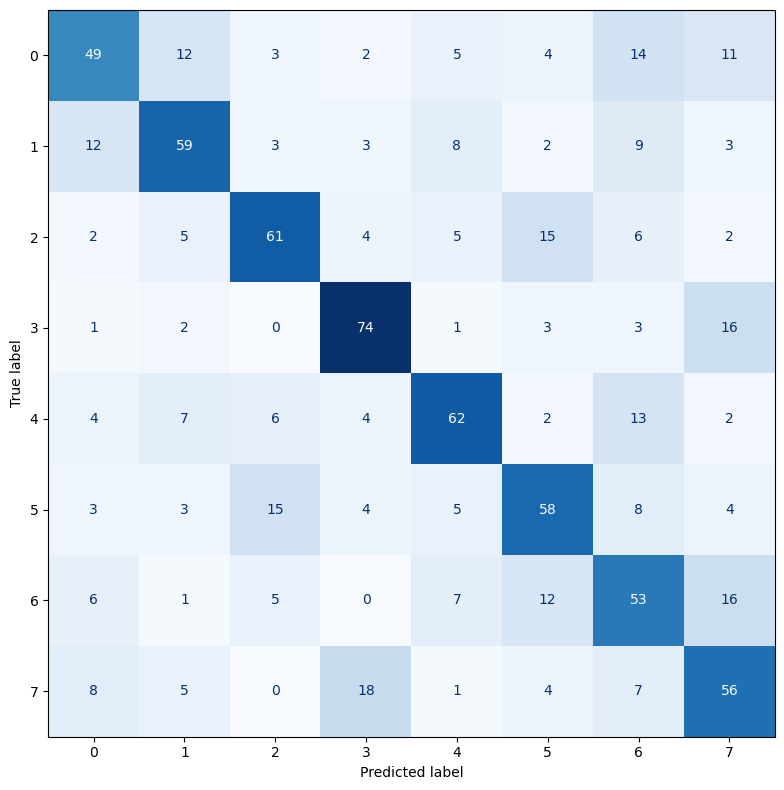

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Assuming y_true, y_pred, and labels are already defined
labels = list(class_to_idx.keys())
print(labels)

def plt_conf_matrix(y_true, y_pred, labels):
    print(y_pred.shape, y_true.shape, (y_pred == y_true).mean())

    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))

    # Create a ConfusionMatrixDisplay instance and plot it
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)  # Adjust cmap and colorbar as needed
    plt.tight_layout()
    plt.show()

# Call the function with your data
plt_conf_matrix(y_val, y_pred, labels)


[0, 1, 2, 4, 5, 6, 7]
(698,) (698,) 0.6017191977077364


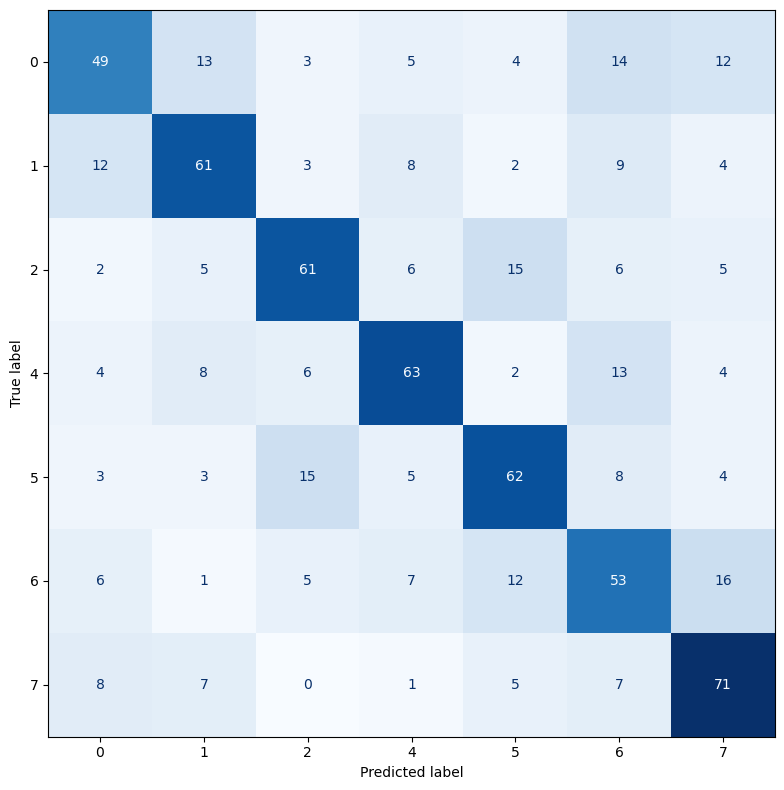

In [35]:
labels_7=[idx_to_class[i] for i in idx_to_class if i!=сontempt_idx]#list(class_to_idx.keys())
print(labels_7)
plt_conf_matrix(y_val_new, y_pred_filtered[other_indices],labels_7)